![copyright](logo.png "Copyright (c) 2017, Bas Hoonhout")

<div style="text-align: right"> Aeolis workshop material Copyright (c) 2017, Bas Hoonhout </div>
<div style="text-align: right"> 2023, Aeolis developer team </div>


# 5A. Long-term Dune Growth — Baseline

**Group activity — Person A**

In this activity your group of four will each run a different AeoLiS model,
then compare results to understand which processes drive long-term dune growth.
Each model adds complexity and builds on the previous one.

| Person | Notebook | Model file | Process added |
|--------|----------|------------|---------------|
| **A (you)** | 5A | `A_long_beach_noveg.txt` | Baseline — aeolian transport only |
| B | 5B | `B_long_beach_no_sed_supply.txt` | + Vegetation growth |
| C | 5C | `C_long_beach_wet_bed_reset.txt` | + Wet bed reset |
| D | 5D | `D_long_beach_constant_SCR.txt` | + Shoreline progradation |

**Your model (A)** is the most basic model, with *no vegetation* and *no beach sediment supply*.
This establishes how the dune system behaves under wind alone, which all other models build on.

Execute cells by selecting the cell and pressing **Shift-Enter**.

## 5A.1. Understand the model 

Open the configuation file and answer the following questions: 

*What is the simulation time?*

*What is the timestep?*

*What is the spatial resolution?*

*What are the boundary conditions and how do they affect the model?*

*What key processes are turned on? Which are turned off?*


Now let's plot some results
----------------------------------

### Helper functions

The file `plot_tools_longtermgrowth.py` contains functions for loading and visualizing model output.
Execute the next cell to import them.

Available functions:
- `extract_netcdf` — load profile data from a netCDF output file
- `plot_profile_evolution` — profiles colored by time (viridis)
- `plot_bed_change` — net erosion / deposition
- `plot_dune_growth` — cross-shore location of the dune toe over time


In [6]:
%matplotlib inline

from plot_tools_longtermgrowth import *

model_A = '../models/A_long_beach_noveg.nc'

## 5A.2 Load model output

In [7]:
x, zbi, zbf, zb_all, rhoveg_all, time, dates = extract_netcdf(model_A)

print(f'Simulation period  : {dates[0].strftime("%Y-%m-%d")}  to  {dates[-1].strftime("%Y-%m-%d")}')
print(f'Output timesteps   : {len(dates)}')
print(f'Cross-shore extent : {x[0]:.0f} to {x[-1]:.0f} m')

Simulation period  : 1997-09-17  to  1999-03-17
Output timesteps   : 274
Cross-shore extent : 0 to 506 m


## 5A.3 Profile evolution

Each line is the cross-shore bed profile at one output timestep.
Color progresses from dark purple (early) to yellow (late).

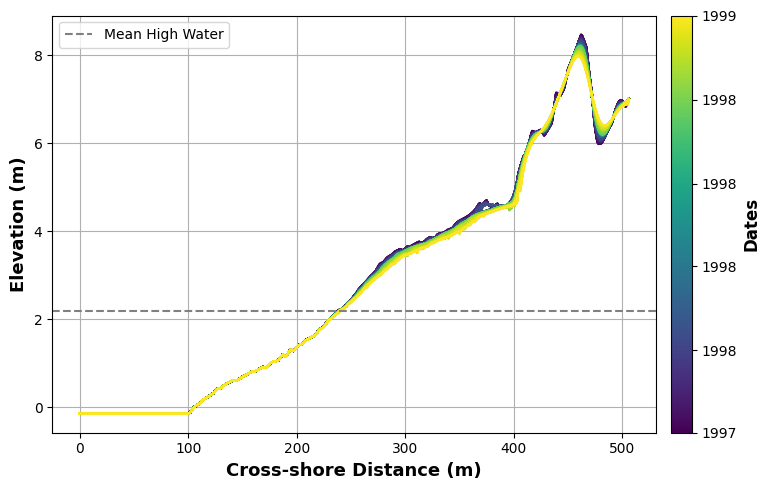

In [8]:
plot_profile_evolution(model_A);

## 5A.4 Net bed-level change

Blue shading = net deposition over the full simulation. Red shading = net erosion.

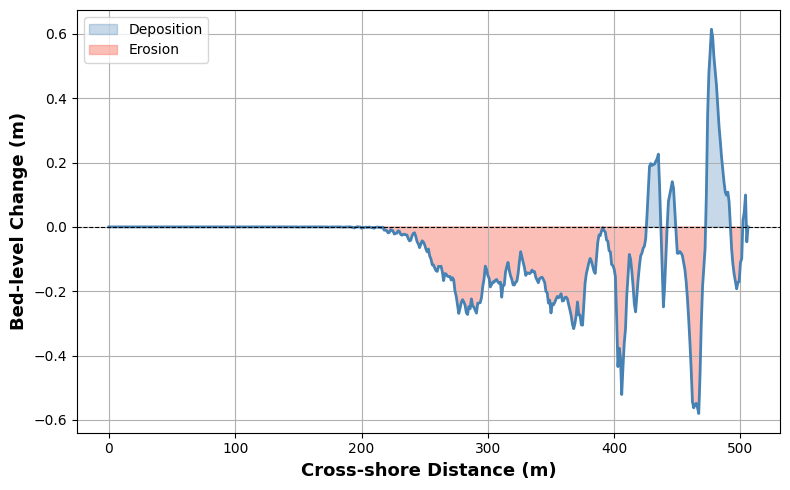

In [9]:
plot_bed_change(model_A);

## 5A.5 Progradation over over time

Dune toe location (4.3 m contour) in the model domain at each output timestep.

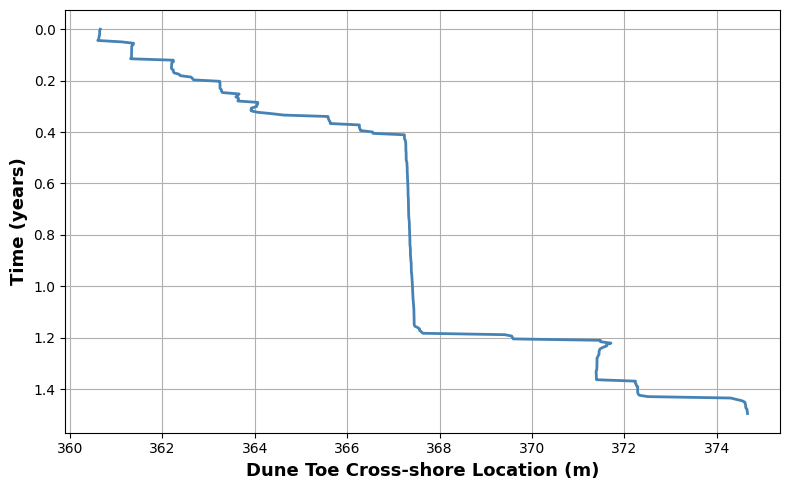

In [10]:
plot_dune_growth(model_A);

---
## 5A.6 Group Discussion

> **We can now compare results with the rest of your group.**

Within your group, take turns showing your screen and discussing the questions below. Go in order of model complexity (A, B, C, D).

## Questions
1. How did the profile change compared to the intial profile?
2. How is the profile changing above mean high water compared to below mean high water?
3. Did the wind or wave forces erode the profile?
4. What process could we add to the model to stabilize the model dune?

---


Congratulations!
-----

You have finished the AeoLiS short course! You have learned to run AeoLiS models and evaluate their input and output. This means you can now start playing around with models that you create yourself! For instance, you can try out different sand fence and vegetation designs, or work on your own model case.

If you choose to continue exploring the long-term model runs, below is a suggested exercise:

1. Open *D_long_beach_constant_SCR.txt* config file.
2. Decrease *tstop* to *63072000* - this will only run two years of the model and decrease the run time to less than 5 minutes. 
3. Change different variables to see what happens! (e.g., *grain_size*, *hveg_max*, *veg_min_elevation*, *method_wet_supply*, etc).
4. Use the helper functions provided above to load and plot your results. Don't forget to change the file name!